In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [94]:
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')

In [13]:
df.shape

(11251, 15)

In [95]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   User_ID           11239 non-null  int64
 1   Cust_name         11239 non-null  str  
 2   Product_ID        11239 non-null  str  
 3   Gender            11239 non-null  str  
 4   Age Group         11239 non-null  str  
 5   Age               11239 non-null  int64
 6   Marital_Status    11239 non-null  int64
 7   State             11239 non-null  str  
 8   Zone              11239 non-null  str  
 9   Occupation        11239 non-null  str  
 10  Product_Category  11239 non-null  str  
 11  Orders            11239 non-null  int64
 12  Amount            11239 non-null  int64
dtypes: int64(5), str(8)
memory usage: 1.2 MB


In [16]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [19]:
pd.isnull(df)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [28]:
df.dropna(inplace=True)

In [29]:
df.shape

(11239, 13)

In [32]:
df['Amount']= df['Amount'].astype('int')

In [34]:
df['Amount'].dtypes

dtype('int64')

In [35]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [41]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


In [42]:
#Exploratory Data Analysis

In [43]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

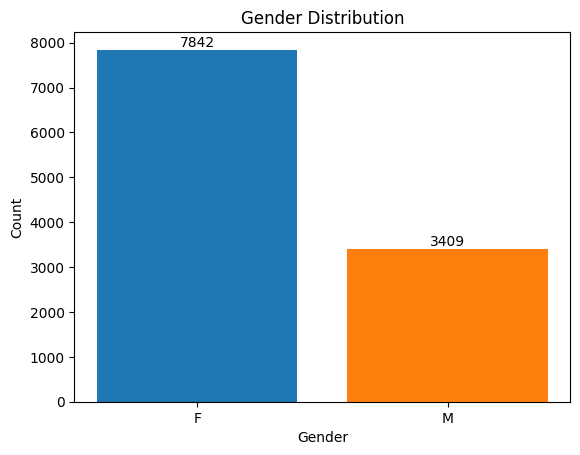

In [133]:
gender_counts = df['Gender'].value_counts()
colors = plt.cm.tab10.colors
bars = plt.bar(gender_counts.index, gender_counts.values,color=colors)
plt.bar_label(bars)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

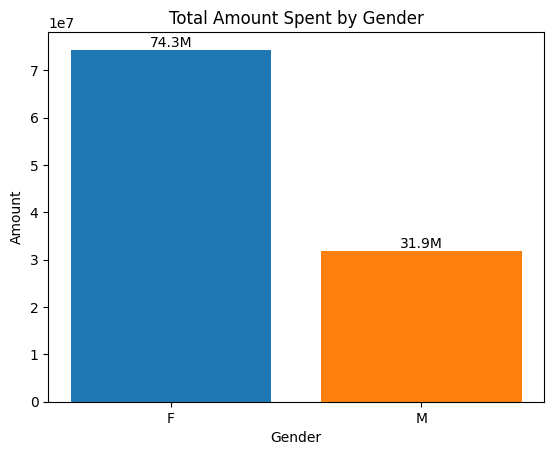

In [132]:
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
colors = plt.cm.tab10.colors
bars = plt.bar(sales_gen['Gender'], sales_gen['Amount'],color=colors)
labels = [f'{v/1e6:.1f}M' for v in sales_gen['Amount']]
plt.bar_label(bars, labels=labels)

plt.xlabel('Gender')
plt.ylabel('Amount')
plt.title('Total Amount Spent by Gender')
plt.show()

>*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

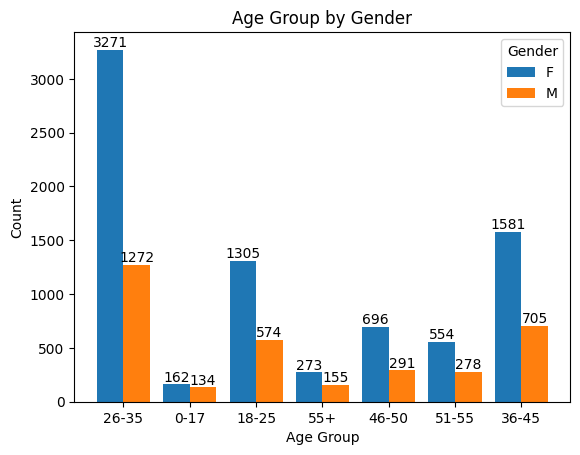

In [127]:
counts = df.value_counts(['Age Group', 'Gender']).unstack()
age_groups = counts.index
x = np.arange(len(age_groups))
bar2 = [i+width for i in x]
width = 0.4

bars_f = plt.bar(x, counts['F'], width, label='F')
bars_m = plt.bar(bar2, counts['M'], width, label='M')

plt.bar_label(bars_f)
plt.bar_label(bars_m)

plt.xticks(x + width/2, age_groups)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Group by Gender')
plt.legend(title='Gender')
plt.show()

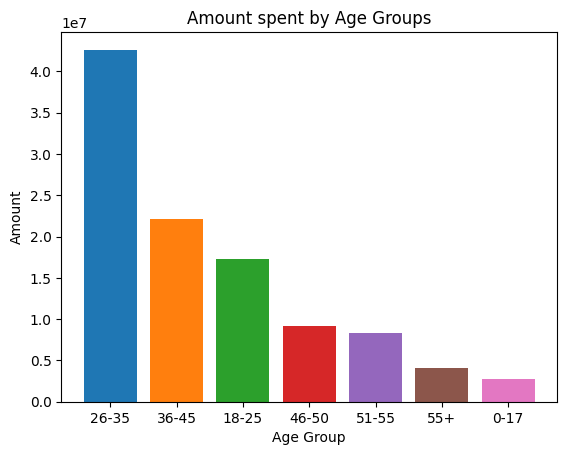

In [128]:
s_age = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
colors = colors = plt.cm.tab10.colors
plt.bar(s_age['Age Group'],s_age['Amount'],color=colors)
plt.xlabel("Age Group")
plt.ylabel("Amount")
plt.title("Amount spent by Age Groups")
plt.show()

>*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

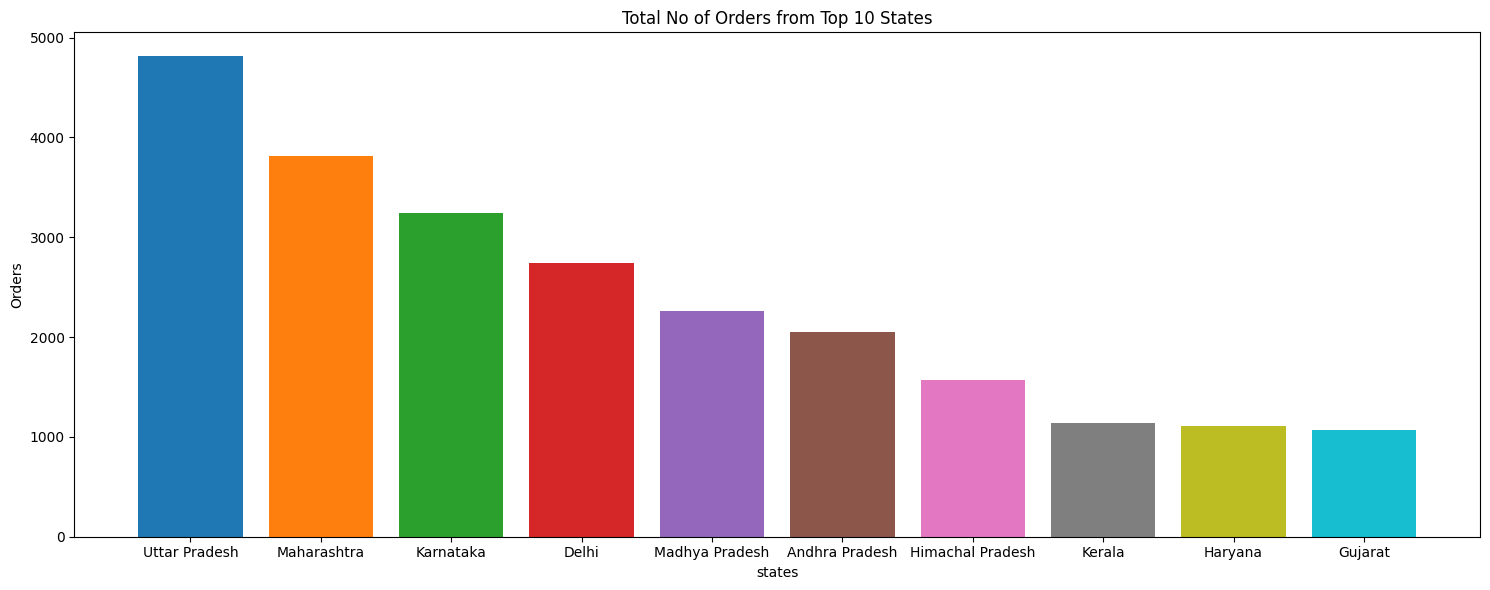

In [129]:
plt.figure(figsize=(15,6))
s_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
colors = plt.cm.tab10.colors
plt.bar(s_state['State'], s_state['Orders'],color=colors)
plt.xlabel("states")
plt.ylabel("Orders")
plt.title("Total No of Orders from Top 10 States")
plt.tight_layout()
#plt.xticks(rotation=90)
plt.show()

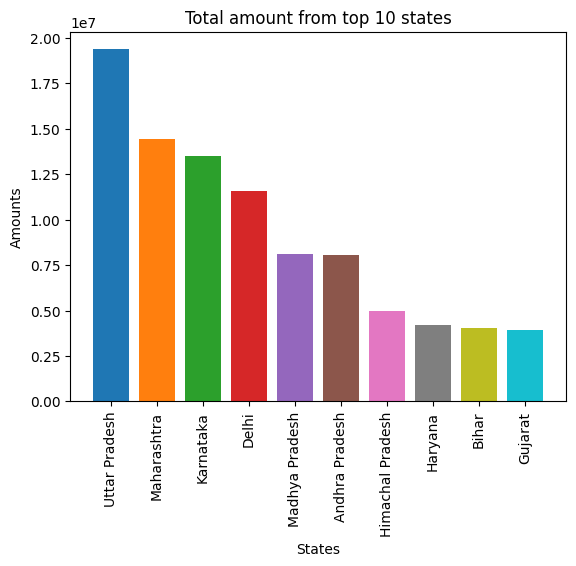

In [130]:
s_state = df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
colors = plt.cm.tab10.colors
plt.bar(s_state['State'],s_state['Amount'],color=colors)
plt.xticks(rotation=90)
plt.xlabel("States")
plt.ylabel('Amounts')
plt.title("Total amount from top 10 states")
plt.show()

>*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*

In [85]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='str')

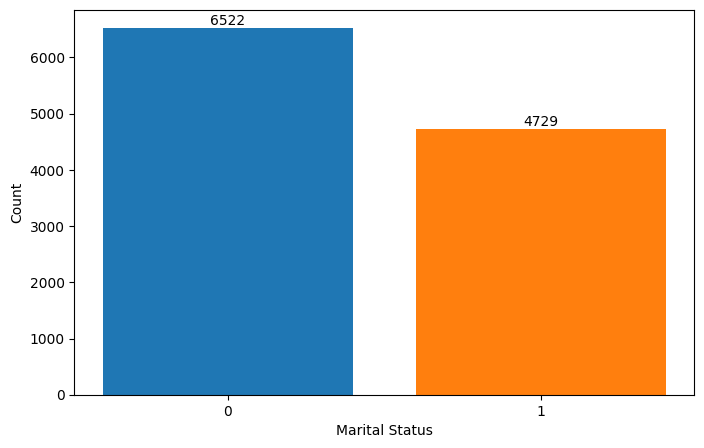

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))   # set size BEFORE drawing, so it actually takes effect

marital_counts = df['Marital_Status'].value_counts()
colors = plt.cm.tab10.colors
bars = plt.bar(marital_counts.index, marital_counts.values,color=colors)
plt.bar_label(bars)
plt.xticks(marital_counts.index, marital_counts.index)

plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

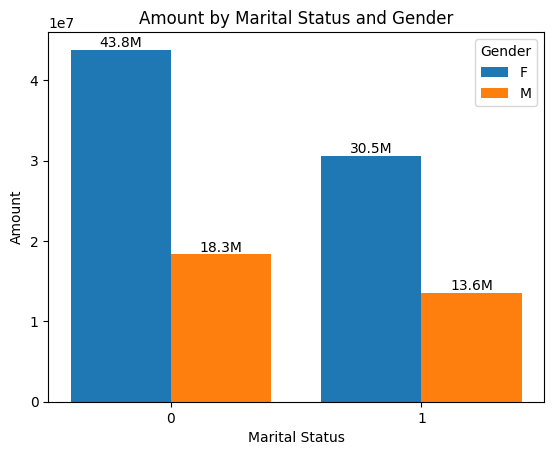

In [188]:
import numpy as np
import matplotlib.pyplot as plt

gen = df.groupby(['Marital_Status', 'Gender'])['Amount'].sum().unstack()

statuses = gen.index
x = np.arange(len(statuses))
bar1= [i+width for i in x]
width = 0.4

bars_f = plt.bar(x, gen['F'], width, label='F')
bars_m = plt.bar(bar1, gen['M'], width, label='M')
labels_f = [f'{v/1e6:.1f}M' for v in gen['F']]
labels_m = [f'{v/1e6:.1f}M' for v in gen['M']]
plt.bar_label(bars_f,labels=labels_f)
plt.bar_label(bars_m,labels=labels_m)

plt.xticks(x +width/2, statuses)
plt.xlabel('Marital Status')
plt.ylabel('Amount')
plt.title('Amount by Marital Status and Gender')
plt.legend(title='Gender')
plt.show()

>*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

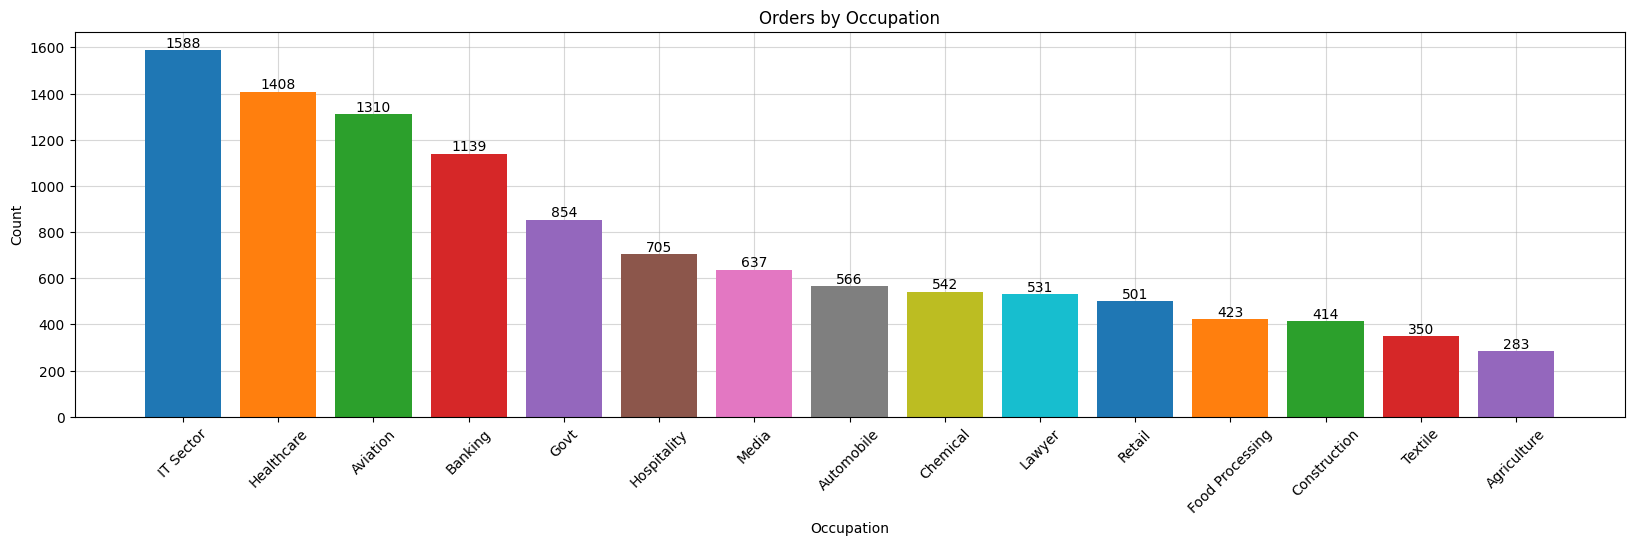

In [23]:
plt.figure(figsize=(20, 5))
colors= plt.cm.tab10.colors
occupation_counts = df['Occupation'].value_counts()

bars = plt.bar(occupation_counts.index, occupation_counts.values,color = colors,zorder=2)
plt.grid(True,zorder=0,alpha=0.5)
plt.xticks(rotation=45)
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.title('Orders by Occupation')
plt.show()

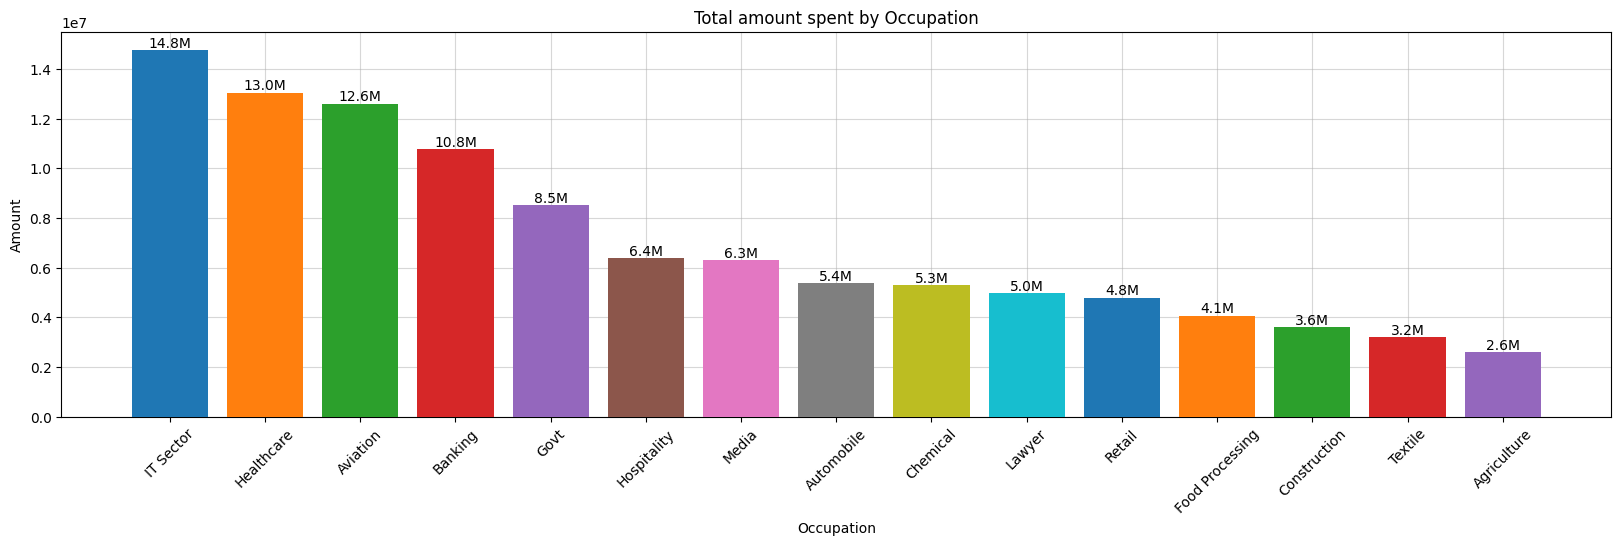

In [50]:
plt.figure(figsize=(20,5))
oc_pur = df.groupby(['Occupation'])['Amount'].sum().sort_values(ascending=False)
colors = plt.cm.tab10.colors
bar = plt.bar(oc_pur.index,oc_pur.values,color=colors,zorder=3)
label=[f'{v/1e6:.1f}M' for v in oc_pur]
plt.bar_label(bar,labels=label)
plt.grid(True,zorder=0,alpha=0.5)
plt.xticks(rotation=45)
plt.xlabel('Occupation')
plt.ylabel('Amount')
plt.title('Total amount spent by Occupation')
plt.show()

>*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

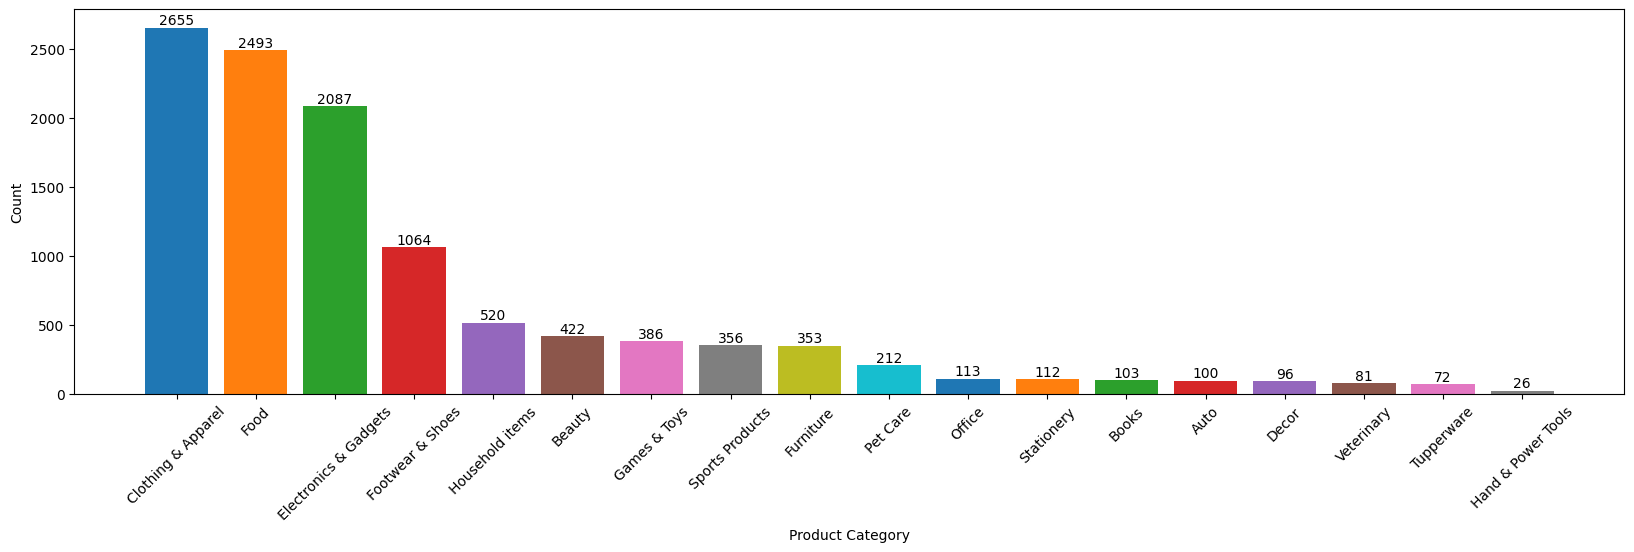

In [68]:
plt.figure(figsize=(20,5))
colors=plt.cm.tab10.colors
prd_cnt=df['Product_Category'].value_counts()
bar = plt.bar(prd_cnt.index,oc_cnt.values,color=colors)
plt.bar_label(bar)
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()


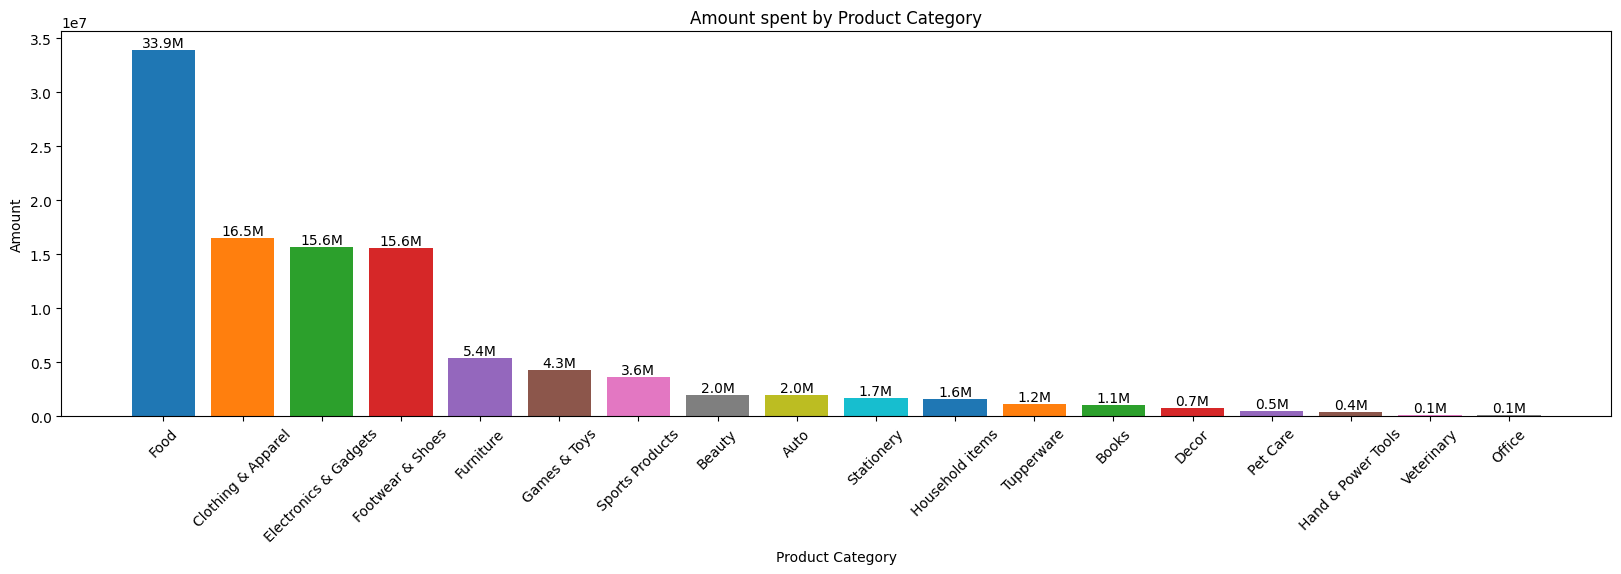

In [130]:
plt.figure(figsize=(20,5))
colors = plt.cm.tab10.colors
prd_amt = df.groupby(['Product_Category'])['Amount'].sum().sort_values(ascending=False)
bar = plt.bar(prd_amt.index,prd_amt.values,color=colors)
label= [f'{v/1e6:.1f}M' for v in prd_amt]
plt.bar_label(bar,labels=label)
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Amount')
plt.title('Amount spent by Product Category')
plt.show()

>*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

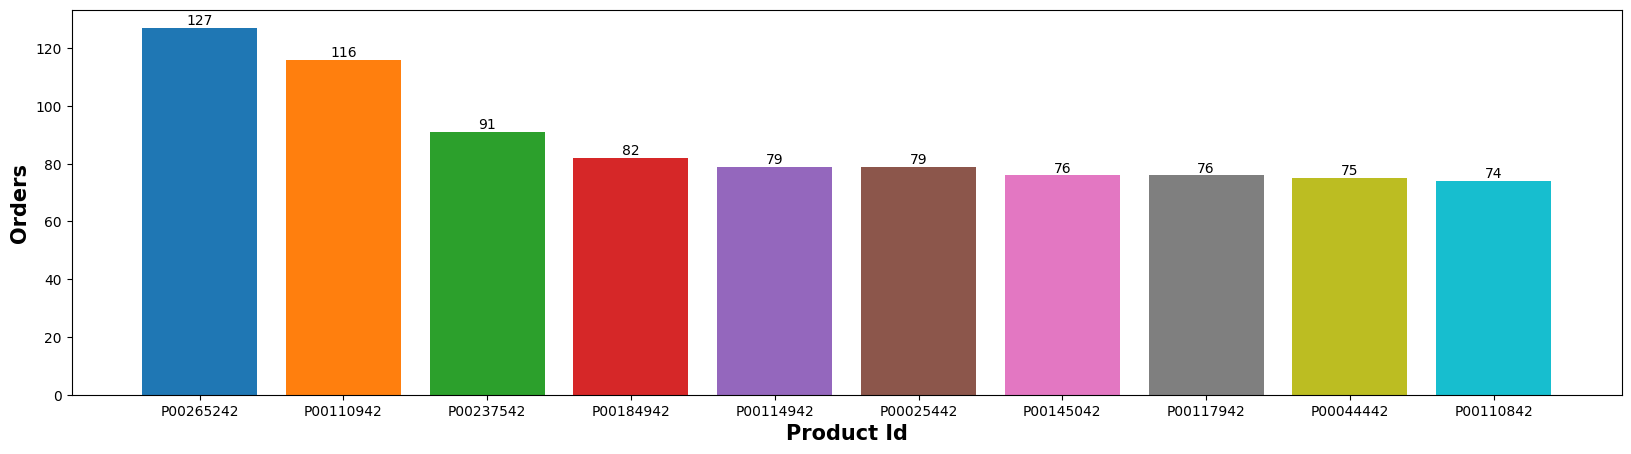

In [125]:
plt.figure(figsize=(20,5))
prd_id = df.groupby(['Product_ID'])['Orders'].sum().sort_values(ascending=False).head(10)
colors = plt.cm.tab10.colors
bar = plt.bar(prd_id.index, prd_id.values, color=colors)
plt.bar_label(bar)
plt.xlabel('Product Id',fontsize=15,fontweight='bold')
plt.ylabel('Orders',fontsize=15,fontweight='bold')
plt.show()

### CONCLUSION

> *Married women age group 26-35 yrs from UP, Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*